# Heart Disease Severity Prediction

### M. Azib Naeem — 23L-2541
### Ahmad Bin Tariq — 23L-2510
### Awais Bin Abbas — 23L-2574

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Reading Data from CSV File

### File Name:
- **heart.csv**

In [66]:
df = pd.read_csv('data\heart_disease_uci.csv')

<>:1: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ahmad\AppData\Local\Temp\ipykernel_30816\3518398687.py:1: SyntaxWarning: invalid escape sequence '\h'
  df = pd.read_csv('data\heart_disease_uci.csv')


In [5]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# Dataset Overview

The dataset contains **920 rows** and **16 columns**. Below are the features:

1. **age** - Age of the patient
2. **sex** - Gender (Male / Female)
3. **cp** - Chest pain type
4. **trestbps** - Resting blood pressure
5. **chol** - Serum cholesterol
6. **fbs** - Fasting blood sugar > 120 mg/dl
7. **restecg** - Resting ECG results
8. **thalch** - Maximum heart rate achieved
9. **exang** - Exercise-induced angina
10. **oldpeak** - ST depression induced by exercise
11. **slope** - Slope of peak exercise ST segment
12. **ca** - Number of major vessels (0–3)
13. **thal** - Thalassemia type
14. **num** - Target variable (0 = No disease, 1–4 = Severity level)

In [7]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


# Checking for NULL Values

In [9]:
df.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

# Visualizing Missing Values

- Red cells represent missing values in the dataset.
- Columns **ca**, **thal**, and **slope** have the most missing data.

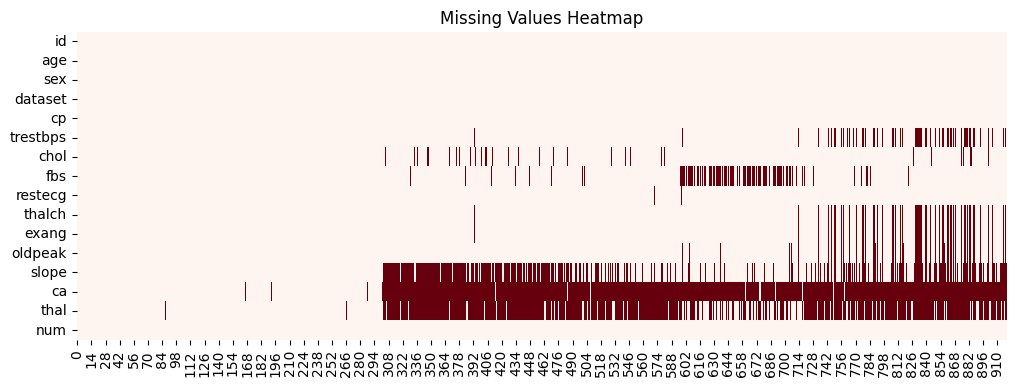

In [10]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull().T, cbar=False, cmap='Reds')
plt.title('Missing Values Heatmap')
plt.show()

# Step 1 — Drop Irrelevant Columns

- **id** — just a row number, no predictive value
- **dataset** — source hospital, introduces data-source bias

In [67]:
df.drop(columns=['id', 'dataset'], inplace=True)
df.shape

(920, 14)

# Target Variable Distribution

- **0** = No heart disease
- **1** = Mild
- **2** = Moderate
- **3** = Severe
- **4** = Very Severe

C:\Users\ahmad\AppData\Local\Temp\ipykernel_30816\3439065065.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num', data=df, palette='muted')


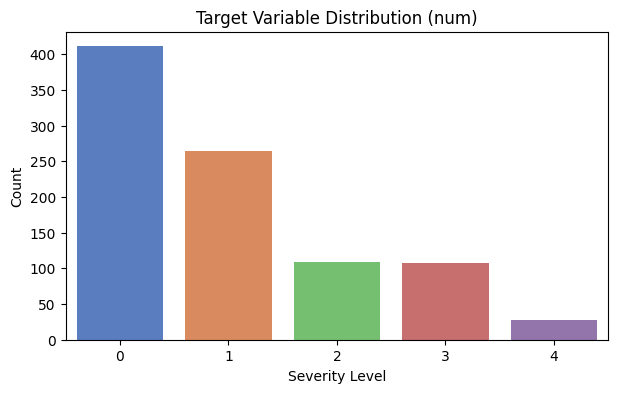

In [12]:
plt.figure(figsize=(7, 4))
sns.countplot(x='num', data=df, palette='muted')
plt.title('Target Variable Distribution (num)')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.show()

# Step 2 — Handle Missing Values

- **Numerical columns** → fill with **median** (robust to outliers)
- **Categorical columns** → fill with **mode** (most frequent value)

In [68]:
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [69]:
cat_cols = ['fbs', 'restecg', 'exang', 'slope', 'thal']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [70]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

# Step 3 — Encode Categorical Variables

- **sex, fbs, exang** → mapped to 0 / 1 (binary)
- **cp, restecg, slope, thal** → One-Hot Encoded

In [71]:
df['sex']   = df['sex'].map({'Male': 1, 'Female': 0})
df['fbs']   = df['fbs'].astype(str).map({'True': 1, 'False': 0})
df['exang'] = df['exang'].astype(str).map({'True': 1, 'False': 0})

In [72]:
df = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)

In [34]:
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145.0,233.0,NaN,150.0,NaN,2.3,0.0,0,False,False,True,False,False,False,False,False,False
1,67,1,160.0,286.0,NaN,108.0,NaN,1.5,3.0,2,False,False,False,False,False,True,False,True,False
2,67,1,120.0,229.0,NaN,129.0,NaN,2.6,2.0,1,False,False,False,False,False,True,False,False,True
3,37,1,130.0,250.0,NaN,187.0,NaN,3.5,0.0,0,False,True,False,True,False,False,False,True,False
4,41,0,130.0,204.0,NaN,172.0,NaN,1.4,0.0,0,True,False,False,False,False,False,True,True,False


# Step 4 — Feature Scaling

- Applied **StandardScaler** on continuous numerical features.
- Makes all features on the same scale — required for SVM.

In [35]:
scaler = StandardScaler()

scale_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [73]:
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145.0,233.0,1,150.0,0,2.3,0.0,0,False,False,True,False,False,False,False,False,False
1,67,1,160.0,286.0,0,108.0,1,1.5,3.0,2,False,False,False,False,False,True,False,True,False
2,67,1,120.0,229.0,0,129.0,1,2.6,2.0,1,False,False,False,False,False,True,False,False,True
3,37,1,130.0,250.0,0,187.0,0,3.5,0.0,0,False,True,False,True,False,False,False,True,False
4,41,0,130.0,204.0,0,172.0,0,1.4,0.0,0,True,False,False,False,False,False,True,True,False


# Exploratory Data Analysis (EDA)

### Age Distribution by Severity Level

<>:1: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ahmad\AppData\Local\Temp\ipykernel_30816\84084168.py:1: SyntaxWarning: invalid escape sequence '\h'
  raw = pd.read_csv('data\heart_disease_uci.csv')
C:\Users\ahmad\AppData\Local\Temp\ipykernel_30816\84084168.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num', y='age', data=raw, palette='muted')


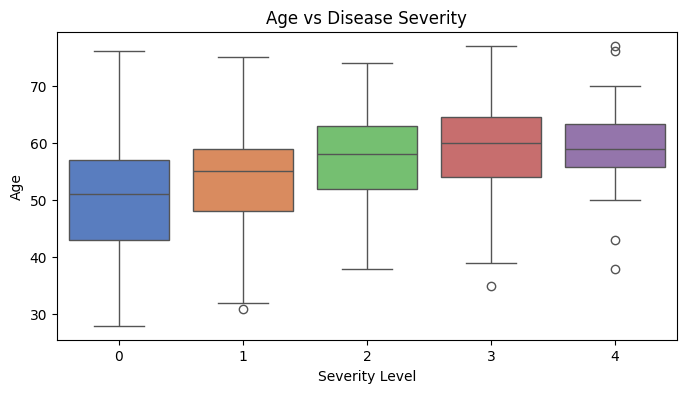

In [38]:
raw = pd.read_csv('data\heart_disease_uci.csv')

plt.figure(figsize=(8, 4))
sns.boxplot(x='num', y='age', data=raw, palette='muted')
plt.title('Age vs Disease Severity')
plt.xlabel('Severity Level')
plt.ylabel('Age')
plt.show()

### Disease Severity by Sex

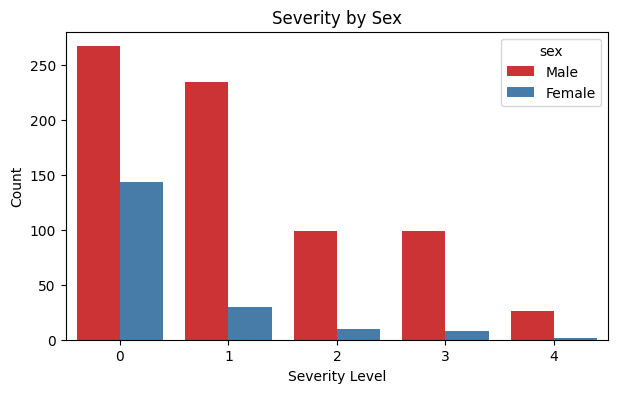

In [39]:
plt.figure(figsize=(7, 4))
sns.countplot(x='num', hue='sex', data=raw, palette='Set1')
plt.title('Severity by Sex')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.show()

### Disease Severity by Chest Pain Type

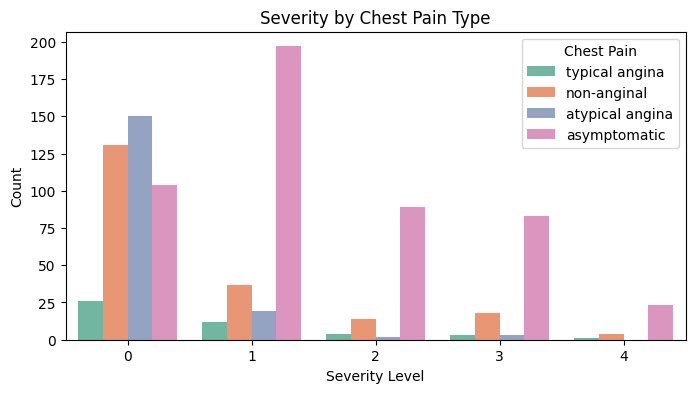

In [40]:
plt.figure(figsize=(8, 4))
sns.countplot(x='num', hue='cp', data=raw, palette='Set2')
plt.title('Severity by Chest Pain Type')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.legend(title='Chest Pain', bbox_to_anchor=(1, 1))
plt.show()

### Cholesterol and Heart Rate Distribution

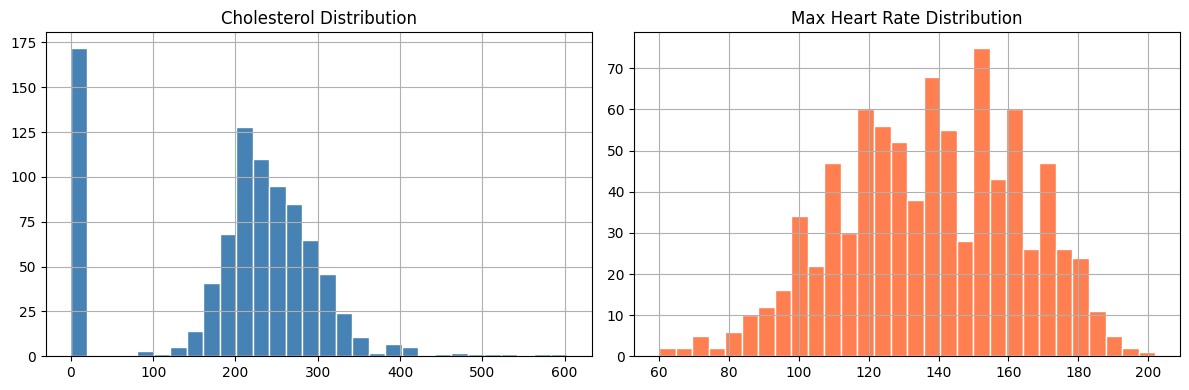

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

raw['chol'].hist(ax=axes[0], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Cholesterol Distribution')

raw['thalch'].hist(ax=axes[1], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Max Heart Rate Distribution')

plt.tight_layout()
plt.show()

### Correlation Heatmap

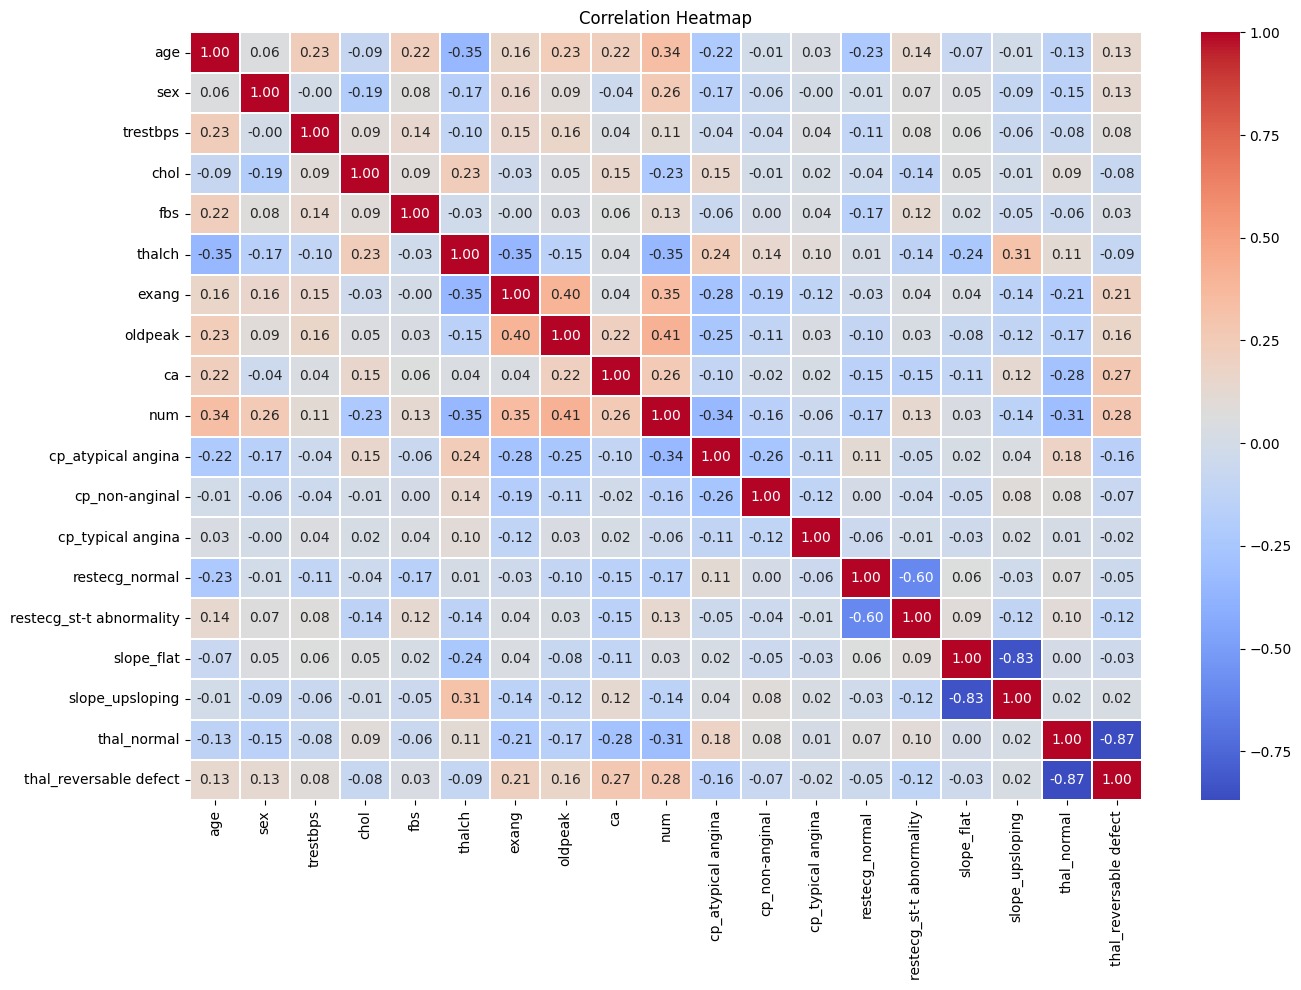

In [74]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.3)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Step 5 — Train / Test Split

- **80%** training data, **20%** testing data
- `stratify=y` ensures all severity classes are proportionally distributed

In [75]:
X = df.drop(columns=['num'])
y = df['num']

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [77]:
print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (736, 18)
Test size : (184, 18)


In [78]:
print('Class distribution (train):')
print(y_train.value_counts().sort_index())

Class distribution (train):
num
0    329
1    212
2     87
3     86
4     22
Name: count, dtype: int64


# Preprocessing Complete ✓

- Missing values handled
- Categorical variables encoded
- Features scaled
- Data split into train and test sets

In [94]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Decision Tree Classifier

- A tree-based model that splits data based on feature conditions
- Simple and interpretable
- Prone to overfitting without depth control

In [80]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [81]:
dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.5380434782608695


In [82]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.74      0.77      0.75        82
           1       0.50      0.43      0.46        53
           2       0.26      0.23      0.24        22
           3       0.22      0.24      0.23        21
           4       0.27      0.50      0.35         6

    accuracy                           0.54       184
   macro avg       0.40      0.43      0.41       184
weighted avg       0.54      0.54      0.54       184



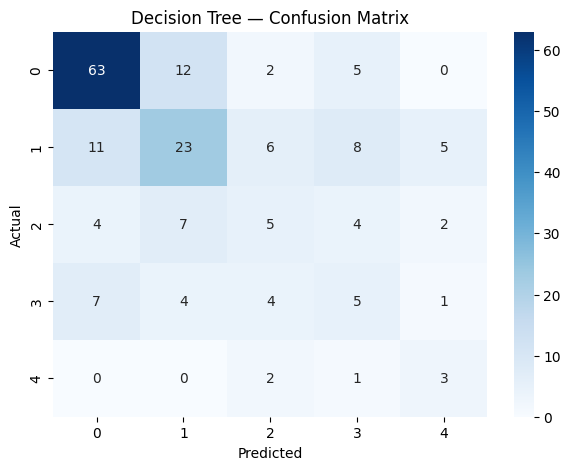

In [83]:
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Random Forest Classifier

- Builds multiple decision trees and takes majority vote
- More accurate and stable than a single Decision Tree
- Reduces overfitting through averaging

In [84]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [85]:
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.5652173913043478


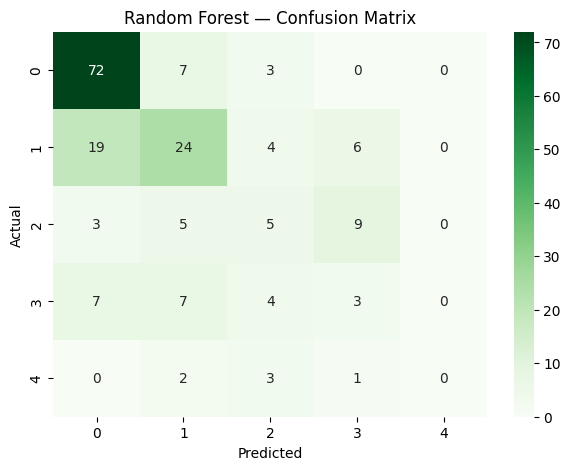

In [86]:
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Support Vector Machine (SVM)

- Finds the best hyperplane to separate classes
- Uses RBF kernel to handle non-linear data
- Works well on small to medium sized datasets

In [87]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [88]:
svm_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.4673913043478261


In [89]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.50      0.93      0.65        82
           1       0.32      0.19      0.24        53
           2       0.00      0.00      0.00        22
           3       0.00      0.00      0.00        21
           4       0.00      0.00      0.00         6

    accuracy                           0.47       184
   macro avg       0.16      0.22      0.18       184
weighted avg       0.31      0.47      0.36       184



c:\Users\ahmad\miniconda3\envs\JupyterProject\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ahmad\miniconda3\envs\JupyterProject\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ahmad\miniconda3\envs\JupyterProject\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

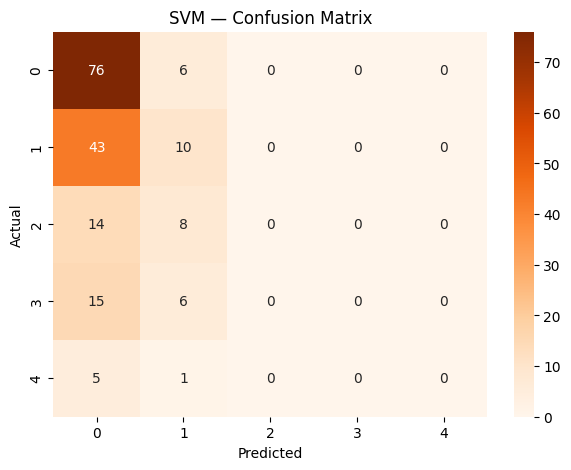

In [90]:
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='Oranges')
plt.title('SVM — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# XGBoost Classifier

- Builds decision trees sequentially
- Each tree corrects the mistakes of the previous one
- One of the most powerful and widely used algorithms

In [95]:
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [96]:
xgb_pred = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.592391304347826


In [97]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.78      0.85      0.81        82
           1       0.52      0.53      0.52        53
           2       0.47      0.32      0.38        22
           3       0.18      0.19      0.19        21
           4       0.00      0.00      0.00         6

    accuracy                           0.59       184
   macro avg       0.39      0.38      0.38       184
weighted avg       0.57      0.59      0.58       184



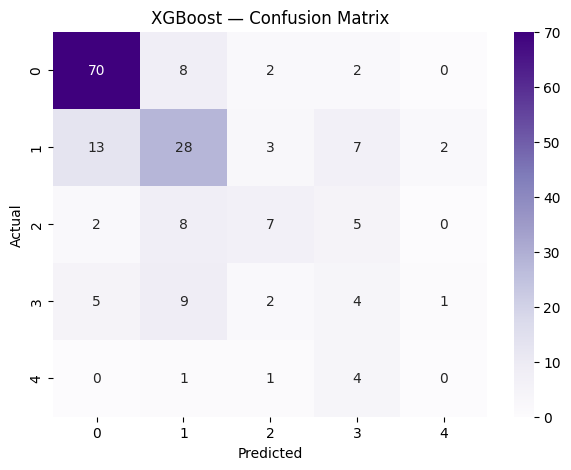

In [98]:
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Purples')
plt.title('XGBoost — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Multi-Class Classification — Model Comparison

- Target variable has **5 levels** (0 = No Disease, 1 = Mild, 2 = Moderate, 3 = Severe, 4 = Very Severe)
- Models are compared on **Accuracy**
- Lower accuracy expected due to 5 classes and small dataset size

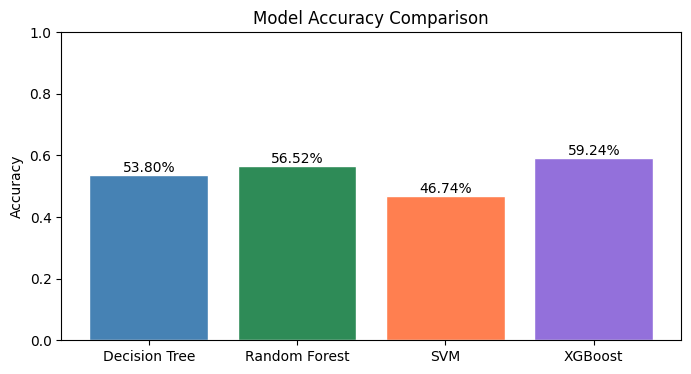

In [99]:
results = {
    'Decision Tree': accuracy_score(y_test, dt_pred),
    'Random Forest': accuracy_score(y_test, rf_pred),
    'SVM'          : accuracy_score(y_test, svm_pred),
    'XGBoost'      : accuracy_score(y_test, xgb_pred)
}

plt.figure(figsize=(8, 4))
plt.bar(results.keys(), results.values(), color=['steelblue', 'seagreen', 'coral', 'mediumpurple'], edgecolor='white')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center')
plt.show()

# Binary Classification

- Target variable converted to **2 classes** only
    - **0** = No Heart Disease
    - **1** = Heart Disease Present (levels 1, 2, 3, 4 merged)
- Simpler problem leads to significantly higher accuracy
- Same 4 models retrained on binary target

In [112]:
y_binary = y.apply(lambda x: 0 if x == 0 else 1)
print(y_binary.value_counts())

num
1    509
0    411
Name: count, dtype: int64


In [113]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

In [117]:
xgb_b = XGBClassifier(random_state=42, eval_metric='logloss')

dt.fit(X_train_b, y_train_b)
rf.fit(X_train_b, y_train_b)
svm.fit(X_train_b, y_train_b)
xgb_b.fit(X_train_b, y_train_b)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [118]:
dt_pred_b  = dt.predict(X_test_b)
rf_pred_b  = rf.predict(X_test_b)
svm_pred_b = svm.predict(X_test_b)
xgb_pred_b = xgb_b.predict(X_test_b)

In [119]:
binary_results = {
    'Decision Tree': accuracy_score(y_test_b, dt_pred_b),
    'Random Forest': accuracy_score(y_test_b, rf_pred_b),
    'SVM'          : accuracy_score(y_test_b, svm_pred_b),
    'XGBoost'      : accuracy_score(y_test_b, xgb_pred_b)
}

# Multi-Class vs Binary — Accuracy Comparison

- Direct comparison of all 4 models on both classification types
- Binary classification consistently outperforms multi-class
- Shows the impact of problem complexity on model performance

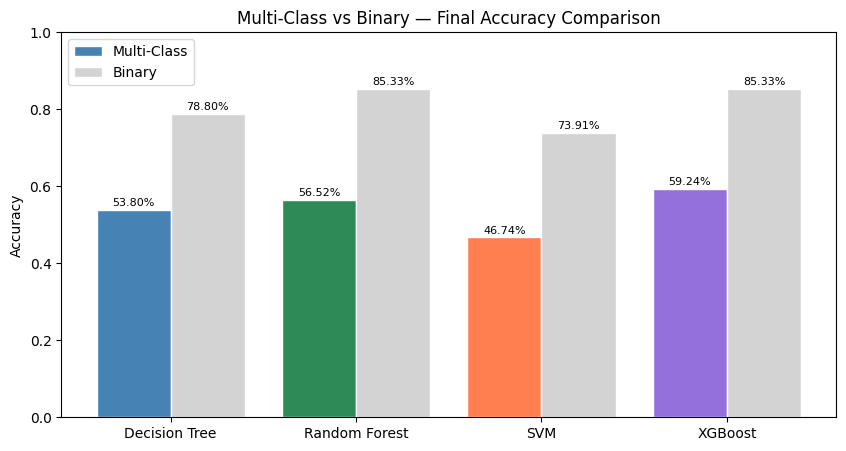

In [ ]:
multi_results = {
    'Decision Tree': accuracy_score(y_test, dt_pred),
    'Random Forest': accuracy_score(y_test, rf_pred),
    'SVM'          : accuracy_score(y_test, svm_pred),
    'XGBoost'      : accuracy_score(y_test, xgb_pred)
}


x = range(len(multi_results))
plt.figure(figsize=(10, 5))
bars1 = plt.bar([i - 0.2 for i in x], multi_results.values(),  width=0.4, label='Multi-Class', color=['steelblue','seagreen','coral','mediumpurple'], edgecolor='white')
bars2 = plt.bar([i + 0.2 for i in x], binary_results.values(), width=0.4, label='Binary',       color='lightgray', edgecolor='white')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2%}', ha='center', fontsize=8)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2%}', ha='center', fontsize=8)

plt.xticks(x, multi_results.keys())
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Multi-Class vs Binary — Final Accuracy Comparison')
plt.legend()
plt.show()

# Final Results Summary

- Complete metrics table for all 4 models
- Covers both Multi-Class and Binary classification
- **Precision** — how many predicted positives were correct
- **Recall** — how many actual positives were caught
- **F1 Score** — balance between Precision and Recall
- Best model is the one with highest F1 Score

In [122]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary = []
for name, pred_m, pred_b in [('Decision Tree', dt_pred,  dt_pred_b),
                               ('Random Forest', rf_pred,  rf_pred_b),
                               ('SVM',           svm_pred, svm_pred_b),
                               ('XGBoost',       xgb_pred, xgb_pred_b)]:
    summary.append({
        'Model'              : name,
        'Multi Accuracy'     : accuracy_score(y_test,   pred_m),
        'Multi Precision'    : precision_score(y_test,  pred_m, average='weighted', zero_division=0),
        'Multi Recall'       : recall_score(y_test,     pred_m, average='weighted', zero_division=0),
        'Multi F1'           : f1_score(y_test,         pred_m, average='weighted', zero_division=0),
        'Binary Accuracy'    : accuracy_score(y_test_b, pred_b),
        'Binary Precision'   : precision_score(y_test_b, pred_b, zero_division=0),
        'Binary Recall'      : recall_score(y_test_b,   pred_b, zero_division=0),
        'Binary F1'          : f1_score(y_test_b,       pred_b, zero_division=0)
    })

summary_df = pd.DataFrame(summary).set_index('Model').round(3)
summary_df

,Multi Accuracy,Multi Precision,Multi Recall,Multi F1,Binary Accuracy,Binary Precision,Binary Recall,Binary F1
Model,,,,,,,,
Decision Tree,0.538,0.539,0.538,0.537,0.788,0.794,0.833,0.813
Random Forest,0.565,0.521,0.565,0.538,0.853,0.844,0.902,0.872
SVM,0.467,0.314,0.467,0.357,0.739,0.750,0.794,0.771
XGBoost,0.592,0.573,0.592,0.580,0.853,0.838,0.912,0.873


# Final Results Summary

## Multi-Class Classification (5 Severity Levels: 0, 1, 2, 3, 4)

| Model         | Accuracy | Precision | Recall | F1 Score |
|---------------|----------|-----------|--------|----------|
| Decision Tree | 53.8%    | 53.9%     | 53.8%  | 53.7%    |
| Random Forest | 56.5%    | 52.1%     | 56.5%  | 53.8%    |
| SVM           | 46.7%    | 31.4%     | 46.7%  | 35.7%    |
| XGBoost       | 59.2%    | 57.3%     | 59.2%  | 58.0%    |

## Binary Classification (0 = No Disease, 1 = Disease Present)

| Model         | Accuracy | Precision | Recall | F1 Score |
|---------------|----------|-----------|--------|----------|
| Decision Tree | 78.8%    | 79.4%     | 83.3%  | 81.3%    |
| Random Forest | 85.3%    | 84.4%     | 90.2%  | 87.2%    |
| SVM           | 73.9%    | 75.0%     | 79.4%  | 77.1%    |
| XGBoost       | 85.3%    | 83.8%     | 91.2%  | 87.3%    |

## Key Observations

- **XGBoost** achieved the best Multi-Class accuracy of **59.2%** and best F1 of **58.0%**
- **XGBoost and Random Forest** tied on Binary accuracy at **85.3%** but XGBoost had higher Recall **(91.2%)**
- **SVM** performed the weakest in both classifications
- Binary classification improved accuracy by approximately **26–30%** across all models
- Low Multi-Class accuracy is expected due to **5 severity levels** and only **920 samples**
- In medical datasets, **Recall is more important than Precision** — catching actual disease cases matters more
- XGBoost is the **recommended model** for this dataset